## CNN-based sign language classifier

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import tensorflow as tf
from sklearn.metrics import confusion_matrix
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

In [17]:
train_data = h5py.File('../datasets/signs_data_training.h5')
test_data = h5py.File('../datasets/signs_data_testing.h5')

In [18]:
train_data.keys(), test_data.keys()

(<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>,
 <KeysViewHDF5 ['list_classes', 'test_set_x', 'test_set_y']>)

In [47]:
X_train = np.array(train_data['train_set_x']).astype('float32') / 255
X_test = np.array(test_data['test_set_x']).astype('float32') / 255

y_train = train_data['train_set_y']
y_test = test_data['test_set_y']

In [48]:
y_train = to_categorical(np.array(y_train))

y_test = to_categorical(np.array(y_test))

In [37]:
print(f"Train Shape: {X_train.shape}, {y_train.shape}")
print(f"Test Shape: {X_test.shape}, {y_test.shape}")

Train Shape: (1080, 64, 64, 3), (1080, 6)
Test Shape: (120, 64, 64, 3), (120, 6)


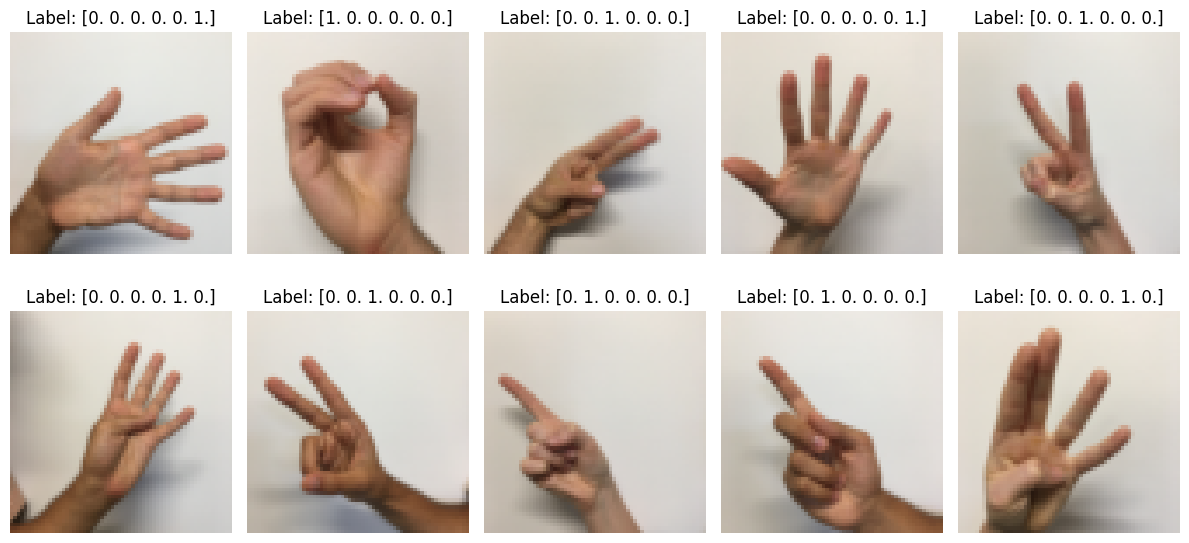

In [38]:
# visualizing top 10 training images

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_train[i])
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [49]:
X_train.shape, X_test.shape

((1080, 64, 64, 3), (120, 64, 64, 3))

In [64]:
#   Building the model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid', activation='relu', input_shape=(64,64,3)))
model.add(MaxPool2D(pool_size=(2,2), strides=2, padding ='valid'))

model.add(Conv2D(64, kernel_size=(3,3),padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2), strides=3, padding ='valid'))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))

model.add(Dense(6, activation='softmax'))

In [65]:
model.build()

In [66]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       409,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,446 (1.64 MB)

 Trainable params: 429,446 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
model.compile(
    loss='categorical_crossentropy',  # Función de pérdida para clasificación multiclase
    optimizer='adam',                 # Optimizador Adam ( algoritmo que ajusta los pesos y sesgos de un modelo durante el entrenamiento para minimizar la función de pérdida)
    metrics=['accuracy']              # Métrica de precisión
)

In [68]:
# Entrenar el modelo
# Utilizamos el método fit() para entrenar el modelo con los datos de entrenamiento (x_train, y_train).
# batch_size=64: Utiliza un tamaño de batch de 64 imágenes por iteración para optimizar la memoria y la velocidad de entrenamiento.
# epochs=5: El modelo entrenará durante 5 épocas (ciclos completos sobre el conjunto de entrenamiento).
# verbose=1: Muestra el progreso del entrenamiento (barras de progreso y métricas).
# validation_data=(x_test, y_test): Utiliza el conjunto de test para evaluar la precisión del modelo al final de cada época.
history = model.fit(X_train, y_train, batch_size=64, epochs=25, verbose=1, validation_data=(X_test, y_test))

Epoch 1/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.1833 - loss: 1.8028 - val_accuracy: 0.2667 - val_loss: 1.7853
Epoch 2/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.2648 - loss: 1.7689 - val_accuracy: 0.1667 - val_loss: 1.7393
Epoch 3/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3843 - loss: 1.6595 - val_accuracy: 0.4583 - val_loss: 1.5477
Epoch 4/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4815 - loss: 1.4462 - val_accuracy: 0.6167 - val_loss: 1.2995
Epoch 5/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.5731 - loss: 1.2030 - val_accuracy: 0.5833 - val_loss: 1.1927
Epoch 6/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6361 - loss: 1.0201 - val_accuracy: 0.7250 - val_loss: 0.9355
Epoch 7/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6861 - loss: 0.8730 - val_accuracy: 0.7500 - val_loss: 0.8456
Epoch 8/25
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.7491 - loss: 0.7509 - val_accuracy: 0.7917 - v

In [69]:
score = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {score[0]}")
print(f"Test accuracy: {score[1]}")

Test loss: 0.2934710681438446
Test accuracy: 0.925000011920929


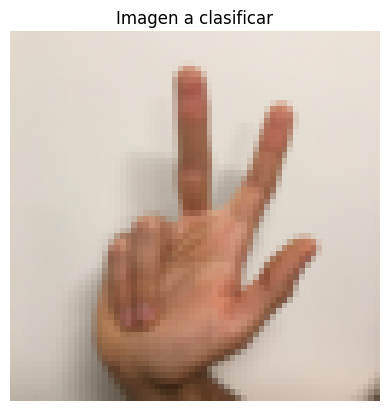

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Predicción (probabilidades): [[5.7628084e-05 3.3775717e-04 1.4006409e-04 9.4165975e-01 4.9710862e-02
  8.0940137e-03]]
Clase predicha: 3
Clase real: [0. 0. 0. 1. 0. 0.]


In [72]:
# Seleccionamos una imagen de prueba (por ejemplo, la primera  segunda del conjunto de test)
index = 6
test_image = X_test[index]

# Mostramos la imagen para referencia
plt.imshow(test_image)
plt.title("Imagen a clasificar")
plt.axis('off')
plt.show()

# Preprocesamos la imagen (si es necesario) y agregamos una dimensión extra para el batch
test_image = np.expand_dims(test_image, axis=0)  # Agregamos dimensión para que sea (1, altura, ancho, canales)

# Realizamos la predicción utilizando el modelo
prediction = model.predict(test_image)

# Imprimimos las probabilidades predichas para cada clase
print("Predicción (probabilidades):", prediction)

# Obtenemos la clase con mayor probabilidad
predicted_class = np.argmax(prediction, axis=1)[0]

# Imprimimos la clase predicha
print(f"Clase predicha: {predicted_class}")

# Mostramos el valor real para comparación
print(f"Clase real: {y_test[index]}")


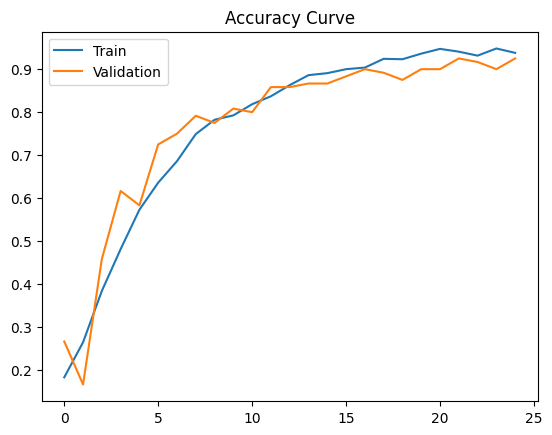

In [73]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

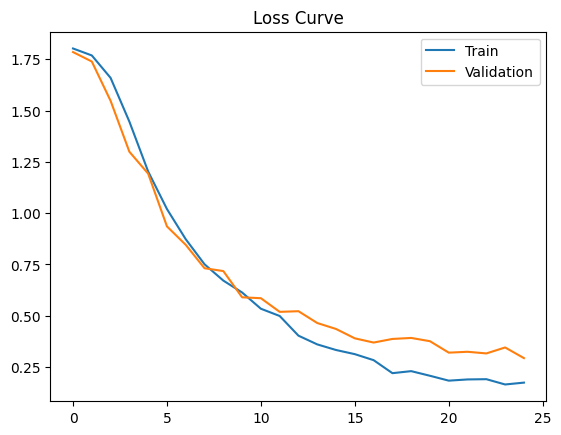

In [74]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss Curve")
plt.legend()
plt.show()

In [75]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9250 - loss: 0.2935
Test Loss: 0.2934710681438446
Test Accuracy: 0.925000011920929


In [76]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)


report = classification_report(y_true, y_pred_classes)
print(report)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.87      1.00      0.93        20
           2       0.94      0.80      0.86        20
           3       0.91      1.00      0.95        20
           4       0.94      0.80      0.86        20
           5       0.90      0.95      0.93        20

    accuracy                           0.93       120
   macro avg       0.93      0.92      0.92       120
weighted avg       0.93      0.93      0.92       120



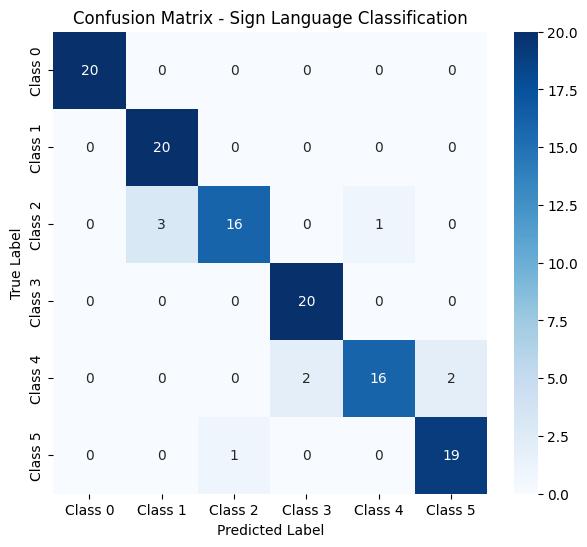

In [77]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Class {i}" for i in range(6)],
    yticklabels=[f"Class {i}" for i in range(6)]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Sign Language Classification")
plt.show()

In [78]:
# Select 10 random test images

indices = np.random.choice(len(X_test), 10 , replace = False)

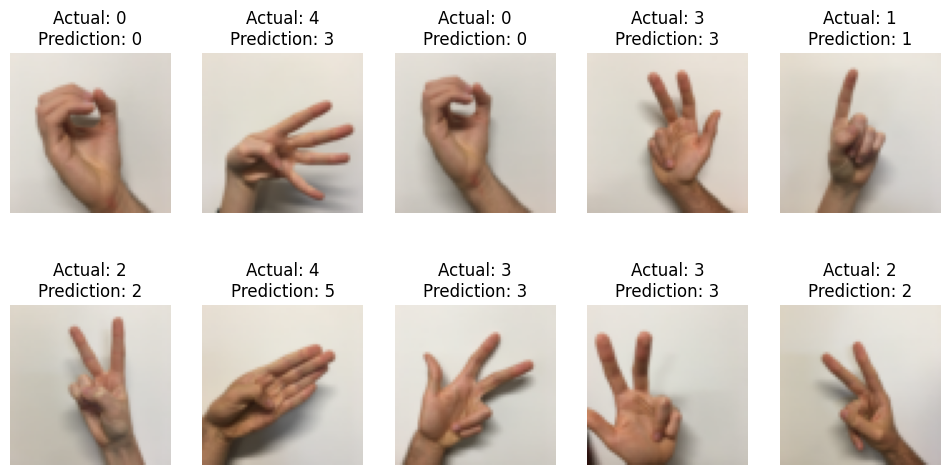

In [79]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx].squeeze(), cmap="gray") # If grayscale cmap="gray"
    ax.set_title(f"Actual: {np.argmax(y_test[idx])}\nPrediction: {y_pred_classes[idx]}")
    ax.axis("off")

plt.show()